In [1]:
import numpy as np
import scipy
from scipy.optimize import curve_fit
import math
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import pickle
plt = sns.mpl.pyplot
from scipy.optimize import fmin_l_bfgs_b


import h5py as h5

import json

# plotting the spec signal data at different temperatures:
import numpy as np
import scipy
from scipy import special

import sys

import ctypes

import time

import datetime
from datetime import datetime
import pytz

import threading

import healpy as hp

import numpy as np
import matplotlib.pyplot as plt
import torch
#!pip install torch pyro-ppl matplotlib numpy
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS

import pyro.distributions.transforms as T

from pyro.infer.autoguide.initialization import init_to_value

from numpy.random import multivariate_normal


/home/ecp/virtual_environment/myenv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Summary of TDC 'calibration':

To characterize the broadening effect due to limited resolution of the TDC (analogously to resolution effect of spectrometer), a TDC calibration was conducted earlier which simply verified the documented uncertainty/deviation of the recorded timestamps vs true time. We assume again a Gaussian broadening effect, with a sigma/std parameter of 55 ps.

Further we respect the limited stability of internal processing of the APD. We just take the documented value(s) for the used APD, that state that it is less than 60 ps and typically less than 40 ps. 

In total we obtain an effective broadening parameter delta of approx. 0.08 ns. As this is very narrow compared to other effects and the true width/duration of POCAM pulses, we simply will subtract this from the effective sigma parameter to obtain true sigma parameter

(mind: sigma_eff^2 = sigma_POCAM^2 + delta^2).

## Modelling the effective and true Time Profile:

The applied model for time profiles is:

- a skewed Gaussian (simple Gaussian x skewing_erf) as the true POCAM time profile,

- weighted by a ~ poissonian factor that accounts for finite ("not perfectly low") occupancy and a slight bias towards earlier arriving photons (mind: dead-time of APD is around < 45 ns),

- and convoluted by the Gaussian broadening due to TDC (and APD) resolution (results in an effective integration)


Since the broadening effect is very narrow (~ peaked like a softened delta-function), compared to other effects and true POCAM pulse-widths, we reduce the convolution of it with the whole POCAM profile and the bias-function to only act on the Gaussian part of the POCAM profile and will respect that in the end when inferring true POCAM parameters (sigma_eff^2 = sigma_POCAM^2 + delta^2). 

Due to simplicity and a minor effect (that we checked and verified to be small), we dropped the bias-function (all factors ~ 1).

## Actual Data Inference:

Here we conduct the actual data inference of the POCAM time profile we want to investigate. From above the procedure should be clear, however there is still the option to include Poissonian errors for the histogram counts, instead of equal weighting in the minimization process (least square) when fitting the binned and 'histogrammized' profile. From experience this typically results in shorter reconstructed true FWHM values, but also in less precise accordance of histogram data points and fitted function... 

In [2]:
class single_tdc_data:
    """ This class is to load and process tdc data for time profiles. """

    def __init__(self, hemisphere='56', 
                 pwm=54000,
                 temp=-20,
                 coarse=1, fine=20,
                 mode='default',
                 diode='LMG520',
                 double_peak=False,
                 uncertainty=True):
        
        
        self.double_peak = double_peak
        

        self.diode = diode
        
        self.hemisphere = hemisphere

        
        self.pwm = pwm
        
        self.coarse = coarse
        self.fine = fine
        
        self.mode = mode
        
        self.temp = temp
        
        self.uncertainty = uncertainty

        
        h5_file_path = f"/home/ecp/test_folder/prod_characterization_{self.hemisphere}/"

        h = h5.File(h5_file_path+self.diode, 'r')

        if 'LMG' in diode:
            try:
                self.target = '1'
                self.driver = 'lmg' + self.target
                self.times_ps = np.array( h[self.driver+'/'+str(self.pwm)+'/'+str(self.coarse)+'-'+str(self.fine)+'/'+str(self.temp)+'C'].get('time_profile') )
                self.mean_occ = float( h[self.driver+'/'+str(self.pwm)+'/'+str(self.coarse)+'-'+str(self.fine)+'/'+str(self.temp)+'C'+'/'+'metadata'].attrs.get('mean_occ') )
            except:
                self.target = '2'
                self.driver = 'lmg' + self.target
                self.times_ps = np.array( h[self.driver+'/'+str(self.pwm)+'/'+str(self.coarse)+'-'+str(self.fine)+'/'+str(self.temp)+'C'].get('time_profile') )
                self.mean_occ = float( h[self.driver+'/'+str(self.pwm)+'/'+str(self.coarse)+'-'+str(self.fine)+'/'+str(self.temp)+'C'+'/'+'metadata'].attrs.get('mean_occ') )
        elif 'KAPU' in diode:
            try:
                self.target = '1'
                self.driver = 'kapu' + self.target
                self.times_ps = np.array( h[self.driver+'/'+str(self.pwm)+'/'+mode+'/'+str(self.temp)+'C'].get('time_profile') )
                self.mean_occ = float( h[self.driver+'/'+str(self.pwm)+'/'+mode+'/'+str(self.temp)+'C'+'/'+'metadata'].attrs.get('mean_occ') )
            except:
                self.target = '2'
                self.driver = 'kapu' + self.target
                self.times_ps = np.array( h[self.driver+'/'+str(self.pwm)+'/'+mode+'/'+str(self.temp)+'C'].get('time_profile') )
                self.mean_occ = float( h[self.driver+'/'+str(self.pwm)+'/'+mode+'/'+str(self.temp)+'C'+'/'+'metadata'].attrs.get('mean_occ') )

            
        # now we actually process the data (also using the defined helper functions etc.)
        # and get some info (fwhm, peak_time, peak, etc.):
        preliminary_hist = np.histogram(self.times_ps/1000.0, 100)
        # preliminary_hist is only used for calculations of approx. peak etc. (display of data is done by code further below)
        # preliminary_hist contains 2 arrays: hist_data[0] are the actual counts and hist_data[1] are the bin edges
        # from this we also extract the approx. time where the peak is (in [ns] units):
        approx_peak_time = preliminary_hist[1][ np.where( preliminary_hist[0] == np.max(preliminary_hist[0]) ) ][0]

        
        
        # then the actual histogram we want to use for plotting etc., restricted to region around the approx. peak time:
        self.histogram = plt.hist( self.times_ps/1000.0, bins=np.linspace(approx_peak_time-60, approx_peak_time+90, 150),
                                  color='green', alpha=0)
        
        
        #plt.close()
        # we close this histogram right after creating and assigning to a memeber-variable,
        # such that it is not add. plotted afterwards when we plot the normalized histogram more below

        # as we want to use interpolations for now, but also if we use fit models instead (-> but requires proper models),
        # we need to process/exract the data in a way that we can interpolate/fit it:
        self.hist_counts = self.histogram[0]
        self.hist_timestamps = self.get_mids(self.histogram)
        
        #print("self.hist_counts: ", self.hist_counts)

        

        #approx_width_old = self.hist_timestamps[self.hist_counts > 0.3*np.max(self.hist_counts)][-1] - self.hist_timestamps[self.hist_counts > 0.3*np.max(self.hist_counts)][0]
        # the 30% (indicated by the factor 0.3) is set arbitrarily but reasonable chosen to search for the fwhm
        
        
        """
        self.corrected_hist_counts, self.correction_factors = poissonian_correction(self.mean_occ, self.hist_counts/np.sum(self.hist_counts))
        
        print("ratio: ")
        print((self.corrected_hist_counts/np.sum(self.corrected_hist_counts))/(self.hist_counts/np.sum(self.hist_counts)))
        print("ratio check: ")
        print((self.corrected_hist_counts/np.sum(self.corrected_hist_counts))/(self.hist_counts/np.sum(self.hist_counts)) - self.correction_factors)
        
        plt.scatter(self.hist_timestamps, self.hist_counts/np.sum(self.hist_counts), color='blue')
        plt.scatter(self.hist_timestamps, self.corrected_hist_counts/np.sum(self.corrected_hist_counts), color='red')
        plt.ylim(0, 1.1*max(np.max(self.hist_counts/np.sum(self.hist_counts)), np.max(self.corrected_hist_counts/np.sum(self.corrected_hist_counts))))
        plt.xlim(100,140)
        plt.show()
        plt.close()
        
        #self.hist_counts = self.corrected_hist_counts
        """
        
        
        self.corrected_hist_counts, self.correction_factors = self.poissonian_correction(self.mean_occ, self.hist_counts)
        #print( len(self.corrected_hist_counts) )
        #print( self.corrected_hist_counts )
        
        
        
        self.peak = np.max(self.hist_counts)
        peak_index = np.where(self.hist_counts == self.peak)[0][0]
        self.peak_time = self.hist_timestamps[peak_index]
        
        # interpolate the shape of the pulse detected by the PMT:
        self.interpolation = scipy.interpolate.InterpolatedUnivariateSpline(self.hist_timestamps, self.hist_counts)
        
        interpolation_time = np.linspace(self.peak_time-30,self.peak_time+30,100)
        interpolation_data = self.interpolation(interpolation_time)
        
        left_times = interpolation_time[interpolation_time < self.peak_time]
        left_data = interpolation_data[:len(left_times)]
        left_index = [ i_ for i_ in range(len(left_times)) if (np.abs(left_data[i_]-0.5*self.peak))==np.min(np.abs(left_data-0.5*self.peak)) ][0]
        self.start = left_times[left_index]
        
        right_times = interpolation_time[interpolation_time > self.peak_time]
        right_data = interpolation_data[-len(right_times):]
        right_index = [ i_ for i_ in range(len(right_times)) if (np.abs(right_data[i_]-0.5*self.peak))==np.min(np.abs(right_data-0.5*self.peak)) ][0]        
        self.end = right_times[right_index]

        approx_width = self.end-self.start
            
        #print("approx_width: ", approx_width)
        
        
        
        
        binning_check = np.linspace(self.peak_time-60, self.peak_time+90, 150, endpoint=False)
        self.histogram_check = np.histogram( self.times_ps/1000.0, bins=binning_check)
        self.hist_counts_check = self.histogram_check[0]
        self.histogram_check_edges = self.histogram_check[1]
        self.hist_timestamps_check = self.get_mids( self.histogram_check )
    
        #print("np.histogram[0]: ", self.histogram[0]/9000 )
        #print("np.histogram[1]: ", self.histogram[1] )
        
        #print("np.histogram_check[0]: ", self.histogram_check[0]/9000 )
        #print("np.histogram_check[1]: ", self.histogram_check[1] )
        
        
        
        
        if self.uncertainty == True:
            self.hist_counts_err = np.sqrt( np.clip(self.hist_counts, 10, None) )
            # 0*np.ones(len(self.hist_counts))
            """
            print( "self.hist_counts:" )
            print( self.hist_counts )

            print( "self.hist_counts_err:" )
            print( self.hist_counts_err )

            print( "rel. err:" )
            print( 1/self.hist_counts_err )
            """
        else:
            pass
        
        
        
        
        
        
        
        if self.double_peak == False:
            # we basically try two initial guesses (unskewed alpha=0 and skewed alpha=1):
            cov_traces = []
            initial_guess = [0, 1, 5, 10]
            for alpha_guess in initial_guess:
                cov_matrix = curve_fit(self.skewed_gaussian, self.hist_timestamps, self.hist_counts,
                                       p0=[approx_peak_time, approx_width, np.max(self.hist_counts), alpha_guess],
                                       maxfev=10000)[1]
                trace = 0
                for i in range(3):
                    trace += cov_matrix[i][i]
                cov_traces.append(trace)
            
            best_guess = initial_guess[ np.where( cov_traces == np.min(cov_traces) )[0][0] ]
            
            if self.uncertainty == True:
                fit, cov = curve_fit(self.skewed_gaussian, self.hist_timestamps, self.hist_counts,
                                     p0=[approx_peak_time, approx_width/2, np.max(self.hist_counts), best_guess],
                                     sigma=self.hist_counts_err,
                                     absolute_sigma=True,
                                     maxfev=10000
                                    )
            else:
                fit, cov = curve_fit(self.skewed_gaussian, self.hist_timestamps, self.hist_counts,
                                     p0=[approx_peak_time, approx_width/2, np.max(self.hist_counts), best_guess],
                                     maxfev=10000
                                    )
            """bounds=([90, -np.inf, -np.inf, -10], 
                       [200, np.inf, np.inf, np.inf]),"""
            
            print("Regular (single) Peak")
            print("fit parameters: [mean, sigma, scaling, alpha]")
            print()
            print("mean: ",fit[0])
            print("sigma: ", fit[1])
            print("scaling: ", 1/9000*fit[2])
            print("alpha: ", fit[3])
            print()
            print("mean_err: ",cov[0][0])
            print("sigma_err: ", cov[1][1])
            print("scaling_err: ", 1/9000*cov[2][2])
            print("alpha_err: ", cov[3][3])
            #print(fit_xdata[-1]-fit_xdata[0])

            #self.fit_function = lambda x: EMG(x, *fit)
            self.fit_function = lambda x: self.skewed_gaussian(x, *fit)
            #mean=fit[0], sigma=fit[1], lamb=fit[2], scale=fit[3], offset=fit[4]
        
        
        else:
            # we basically try two initial guesses (unskewed alpha=0 and skewed alpha=1):
            cov_traces = []
            initial_guess = [0, 1, 5, 10]
            for alpha_guess in initial_guess:
                cov_matrix = curve_fit(self.skewed_double_gaussian, self.hist_timestamps, self.hist_counts,
                                       p0=[approx_peak_time, approx_width, np.max(self.hist_counts), alpha_guess, approx_peak_time+10, approx_width*2/3, np.max(self.hist_counts)/7],
                                       #bounds=([0, 0, 0, -10, 0+10, 0, 0], [np.inf, np.inf, np.inf, 20, np.inf, np.inf, np.inf]),
                                       maxfev=10000)[1]
                
                trace = 0
                for i in range(3):
                    trace += cov_matrix[i][i]
                cov_traces.append(trace)

            best_guess = initial_guess[ np.where( cov_traces == np.min(cov_traces) )[0][0] ]
            
            if self.uncertainty == True:
                fit, cov = curve_fit(self.skewed_double_gaussian, self.hist_timestamps, self.hist_counts,
                                     p0=[approx_peak_time, approx_width, np.max(self.hist_counts), best_guess, approx_peak_time+10, approx_width*2/3, np.max(self.hist_counts)/7],
                                     sigma=self.hist_counts_err,
                                     absolute_sigma=True,
                                     maxfev=10000
                                    )
            else:
                fit, cov = curve_fit(self.skewed_double_gaussian, self.hist_timestamps, self.hist_counts,
                                     p0=[approx_peak_time, approx_width, np.max(self.hist_counts), best_guess, approx_peak_time+10, approx_width*2/3, np.max(self.hist_counts)/7],
                                     #bounds=([0, 0, 0, -10, 0+10, 0, 0], [np.inf, np.inf, np.inf, 20, np.inf, np.inf, np.inf]),
                                     maxfev=10000
                                    )
            """bounds=([90, -np.inf, -np.inf, -10, 100, 0, 0], 
                       [200, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf]),"""
            
            print("Double peak")
            print("fit parameters: [mean, sigma, scaling, alpha, mean_2, sigma_2, scaling_2]")
            print()
            print("mean: ",fit[0])
            print("sigma: ", fit[1])
            print("scaling: ", 1/9000*fit[2])
            print("alpha: ", fit[3])
            print("mean_2: ", fit[4])
            print("sigma_2: ", fit[5])
            print("scaling_2: ", 1/9000*fit[6])
            print()
            print("mean_err: ",cov[0][0])
            print("sigma_err: ", cov[1][1])
            print("scaling_err: ", 1/9000*cov[2][2])
            print("alpha_err: ", cov[3][3])
            print("mean_2_err: ", cov[4][4])
            print("sigma_2_err: ", cov[5][5])
            print("scaling_2_err: ", 1/9000*cov[6][6])
            #print(fit_xdata[-1]-fit_xdata[0])

            #self.fit_function = lambda x: EMG(x, *fit)
            self.fit_function = lambda x: self.skewed_double_gaussian(x, *fit)
            #mean=fit[0], sigma=fit[1], lamb=fit[2], scale=fit[3], offset=fit[4]
            
            
            
            # Furthermore, for double peaks we want to give a short statement on the ~ overall contribution 
            # of the second peak:
            self.second_peak_contr = round( np.sum( np.array(self.hist_counts[np.abs(self.hist_timestamps - fit[4]) < 2.3548 * np.abs(fit[5])]) ) / np.sum(self.hist_counts) , 4 )
            #print("second_peak_contr: ", second_peak_contr)
            
            
        
        
        self.fit = fit
        self.cov = cov

        self.norm = 1 / np.sum(self.hist_counts)
        
        
        
        
        # These lines are already respecting the fact that we detect an effective sigma parameter
        # as a convolution of true POCAM sigma and the broadening effect of TDC and APD:
        self.delta_broadening = 0.08 ## TDC and APD broadening effect in [ns]
        
        self.sigma_eff = self.fit[1]
        self.sigma_eff_std = np.sqrt( np.abs( self.cov[1][1] ) )
        
        self.sigma_POCAM = np.sqrt( self.sigma_eff**2 - self.delta_broadening**2 )
        self.fit[1] = self.sigma_POCAM
        self.sigma_POCAM_err = self.sigma_eff / self.sigma_POCAM * self.sigma_eff_std**2
        self.cov[1][1] = self.sigma_POCAM_err
        
        
    
        
        x_range = np.linspace(90, 140, 15000)
        if self.double_peak == True:
            self.fwhm, self.fwhm_std = self.compute_fwhm_MC(self.skewed_double_gaussian, self.fit, self.cov, x_range)
        else:
            self.fwhm, self.fwhm_std = self.compute_fwhm_MC(self.skewed_gaussian, self.fit, self.cov, x_range)
        print()
        print("MC results:")
        print("self.fwhm: ", round(self.fwhm,2) , " +/- ", round(self.fwhm_std,2))
        
        
        
        
        print()
        self.pocam_fwhm = round(self.fwhm,2)
        self.pocam_fwhm_err = round( np.sqrt(self.fwhm_std**2 + 2*0.08**2),2 )
        print( "POCAM FWHM: ", self.pocam_fwhm, " +/- ", self.pocam_fwhm_err )
        
        
    
        

        
        
        # also extract the meas_time in unix time format:
        # datetime string in local time (Munich, Germany)
        if 'LMG' in diode:
            dt_str = h[self.driver+'/'+str(54000)+'/'+str(1)+'-'+str(20)+'/'+str(25)+'C'+'/'+'metadata'].attrs.get('datetime')  #'2025-04-13 22:12:41.830819'
        elif 'KAPU' in diode:
            dt_str = h[self.driver+'/'+str(54000)+'/'+'default'+'/'+str(25)+'C'+'/'+'metadata'].attrs.get('datetime')  #'2025-04-13 22:12:41.830819'
        date = dt_str.split(' ')[0]
        self.date = ''
        for ymd in date.split('-'):
            self.date += ymd
        #print(self.date)
        # Step 1: Parse the naive datetime (no timezone yet)
        dt_naive = datetime.strptime(dt_str, '%Y-%m-%d %H:%M:%S.%f')
        # Step 2: Localize to Europe/Berlin timezone (handles DST)
        munich_tz = pytz.timezone('Europe/Berlin')
        dt_local = munich_tz.localize(dt_naive)
        # Step 3: Convert to UTC
        dt_utc = dt_local.astimezone(pytz.utc)
        # Step 4: Convert to Unix timestamp
        unix_time = dt_utc.timestamp()
        self.meas_time = unix_time
        #print("Unix time:", unix_time)
        
        
        h.close()
        
        
        
        

        """
        max_scan = np.linspace(approx_peak_time-25, approx_peak_time+25, 50000)
        # get peak time via fitting:
        self.peak_time = max_scan[np.where(self.fit_function(max_scan)==np.max(self.fit_function(max_scan)))[0]] [0]
        # and extract height of the peak, but directly as the highest value from the data:
        self.peak = np.max( self.histogram[0] )

        x_right = np.linspace(self.peak_time, self.peak_time+25, 25000)
        right_dist = np.abs(self.fit_function(x_right)-self.fit_function(self.peak_time)/2)
        right_min = np.min(right_dist)
        self.right = x_right[np.where(right_dist==right_min)[0]][0]

        x_left = np.linspace(self.peak_time-20, self.peak_time, 25000)
        left_dist = np.abs(self.fit_function(x_left)-self.fit_function(self.peak_time)/2)
        left_min = np.min(left_dist)
        self.left = x_left[np.where(left_dist==left_min)[0]][0]

        fwhm = self.right - self.left
        self.fwhm = round(fwhm,2)
        """

        
        

    # some helper function:
    # ( basically only for analysing data (peak-pos., fwhm,...) and eventually including it into plot )
    def get_mids(self, histogram):
        """Get the mids (length N-1) of an array with length N. Usually applied to get the mids of bins."""
        # this function returns you a np.array with len(array)-1 entries
        # entry with index i is the mid of a[i] and a[i+1]
        array = histogram[1]
        return(0.5 * (array[:-1] + array[1:]))

    
    
    
    
    
    def poissonian_correction(self, mean_occ, hist_counts):
        count_norm = 9000 # 9000 , if we want to reduce true counts to their probability values of bins 
        poissonian_factors = []
        corrected_hist_counts = []
        for i in range(len(hist_counts)):
            correction_factor = 1
            for j in range(i):
                if i == 0:
                    correction_factor = 1
                else:
                    correction_factor *= np.exp(+mean_occ*1/count_norm*corrected_hist_counts[j])
            corrected_value = correction_factor * hist_counts[i]
            poissonian_factors.append(correction_factor)
            corrected_hist_counts.append(corrected_value)
        corrected_hist_counts = np.array(corrected_hist_counts)
        poissonian_factors = np.array(poissonian_factors)
        return(corrected_hist_counts, poissonian_factors)
    
    
    
    
    
    
    
    def compute_fwhm(self, fit_func, args, x_range):
        y_vals = fit_func(x_range, *args)
        half_max = np.max(y_vals) / 2
        indices = np.where(y_vals >= half_max)[0]
        if len(indices) < 2:
            return np.nan  # Fit failed
        fwhm_val = x_range[indices[-1]] - x_range[indices[0]]
        return fwhm_val
    
    
    
    def compute_fwhm_MC(self, fit_func, popt, pcov, x_range, N=1000):
        param_mask = [0, 1, 3]  # mean, sigma, alpha
        popt_reduced = np.array(popt)[param_mask]
        pcov_reduced = pcov[np.ix_(param_mask, param_mask)]

        samples_reduced = multivariate_normal(popt_reduced, pcov_reduced, size=N)

        fwhms = []
        for sample in samples_reduced:
            full_params = popt.copy()
            full_params[0] = sample[0]  # mean
            full_params[1] = sample[1]  # sigma
            full_params[3] = sample[2]  # alpha

            fwhm = self.compute_fwhm(fit_func, full_params, x_range)
            fwhms.append(fwhm)

        fwhm_mean = np.mean(fwhms)
        fwhm_std = np.std(fwhms)
        #print(fwhms)
        return fwhm_mean, fwhm_std

    

    
    
    def gaussian(self, x, mean, sigma):
        values = 1/(np.sqrt(2*math.pi)*sigma) * np.exp(-1/(2*sigma**2)*(x-mean)**2)
        return(values) 
    
    def skewing_erf(self, x, mean, sigma, alpha):
        values = 1/2 * ( 1 + special.erf(alpha*(x-mean)/(np.sqrt(2)*sigma)) )
        return(values)
    
    def skewed_gaussian(self, x, mean, sigma, scaling, alpha):
        ''' This function just gives you the pdf of a normal/gaussian distribution,
            which is skewed to one side, and eventually has a scale and offset parameter. '''
        values = scaling * 2*(self.gaussian(x, mean, sigma)*self.skewing_erf(x, mean, sigma, alpha))
        return(values)
    
    
    

    
    def skewed_double_gaussian(self, x, mean, sigma, scaling, alpha, mean_2, sigma_2, scaling_2):
        '''   '''
        first_peak = scaling * 2*(self.gaussian(x, mean, sigma)*self.skewing_erf(x, mean, sigma, alpha))
        second_peak = scaling_2 * self.gaussian(x, mean_2, sigma_2)
        values = first_peak + second_peak
        return(values)

    
    
#single_tdc_data()
    

In [3]:

class temp_dependent_tdc_data:
    
    """ Things You want to mind when using this function:
         - of course handing over the correct parameters when instantiating
         - adjust here also the path (h5_file_path) in the single_tdc_data() class, from where to load the h5 file if needed
         - we make use of the class single_tdc_data() to process the spec datasets
         - you may want to adjust the colors and make sure that the list contains enough different colors (colors), depending on what you want to display/plot
         - for more info on what names for certain parameters are allowed or what data is even there to be accessed, you may also just open the h5 file and look through it
         - if you actually want to store the data just out-comment the plt.savefig() line and set the storing path correctly/where you want it to store
         - last but not least you have to call this function of course to do what it is supposed to do"""

    def __init__(self,
                 hemisphere='04',
                 temps = [25, 0, -10, -20, -30, -40],
                 diode = 'LMG520',
                 power = 54000,
                 coarse = 2, fine = 20,
                 mode = 'default',
                 double_peak=False,
                 uncertainty=False,
                 plotting=True):
        
        
        self.double_peak = double_peak
        

        self.diode = diode
        
        self.hemisphere = hemisphere

        
        self.pwm = power
        self.power = power
        
        self.coarse = coarse
        self.fine = fine
        
        self.mode = mode
        
        self.temp = temps[0]
        
        self.uncertainty = uncertainty
        
        
        
        
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(1, 1, 1)

        alphas = [0.6, 0.6, 0.6, 0.6, 0.6, 0.6]


        if diode=="LMG520":
            colors = ['darkgreen', 'olive', 'green', 'mediumseagreen', 'limegreen', 'springgreen']
        elif diode=="LMG450" or diode=="KAPU465":
            colors = ['darkblue', 'blue', 'royalblue', 'cornflowerblue', 'darkturquoise', 'cyan']
        elif diode=="LMG405" or diode=="KAPU405":
            colors = ['midnightblue', 'blue', 'royalblue', 'cornflowerblue', 'steelblue', 'deepskyblue']
        elif diode=="LMG365":
            colors = ['indigo', 'darkmagenta', 'mediumvioletred', 'magenta', 'hotpink', 'deeppink']


        max_height = []


        for i in range(len(temps)):
            try:
                temp = temps[i]

                tdc = single_tdc_data(hemisphere=hemisphere,pwm=power, temp=temp, 
                                      coarse=coarse, fine=fine, mode=mode, diode=diode, double_peak=double_peak, uncertainty=uncertainty)
                self.tdc = tdc
                
                alpha = alphas[i]
                color = colors[i]
                
                
                times_ps = tdc.times_ps
                self.times_ps = tdc.times_ps

                mean_occ = tdc.mean_occ
                self.mean_occ = tdc.mean_occ

                fwhm = tdc.fwhm
                self.fwhm = tdc.fwhm

                norm = tdc.norm
                self.norm = tdc.norm

                peak_time = tdc.peak_time
                self.peak_time = tdc.peak_time

                peak = tdc.peak
                self.peak = tdc.peak

                temp = tdc.temp
                self.temp = tdc.temp

                fit_function = tdc.fit_function
                self.fit_function = tdc.fit_function
                
                
                
                if double_peak == True:
                    print()
                    self.second_peak_contr = round( tdc.second_peak_contr , 4 )
                    self.second_peak_fwhm = round( 2.3548*np.abs(tdc.fit[5]) , 2 )
                    self.second_peak_mean = round( tdc.fit[4] , 2 )
                    self.first_peak_mean = round( tdc.fit[0] , 2 )
                    self.second_peak_delay = round( self.second_peak_mean - self.first_peak_mean , 2 )
                    print("~ second peak contribution [%]: ", 100*self.second_peak_contr)
                    print("~ second peak FWHM [ns]: ", self.second_peak_fwhm)
                    print("~ second peak delay time after main peak [ns]: ", round( self.second_peak_delay, 2 ) )
                else:
                    pass
                
                # and some timing info:
                self.date = tdc.date
                self.meas_time = tdc.meas_time



                np_times = np.histogram((self.times_ps)/1000.0, bins=150, range=(self.peak_time-60, self.peak_time+90))[1]
                np_counts = np.histogram((self.times_ps)/1000.0, bins=150, range=(self.peak_time-60, self.peak_time+90))[0]

                """
                np_counts, corr = poissonian_correction(mean_occ, np_counts)
                """


                np_times = np.delete(np_times, len(np_times)-1)


                offset = np_times[np_counts>20][0]
                adjust = offset - 100


                hist_bins = np.linspace(self.peak_time-60-adjust, self.peak_time+90-adjust, 150, endpoint=False)

                histogram = plt.hist((self.times_ps)/1000.0 - adjust, bins=hist_bins,
                                     histtype='step', color=color, weights=norm*np.ones(len(self.times_ps)),
                                     label=f"T: {temp} °C \nFWHM = {round(fwhm,2)} ns")
                
                #print( np.sum(np.array(histogram[0])) )
                

                """
                corr_histogram = tdc.correction_factors * plt.hist((times_ps)/1000.0 - adjust, bins=hist_bins,
                                     histtype='step', color='orange', weights=norm*np.ones(len(times_ps)),
                                     label=f"Poissonian-corrected Counts")
                """


                hist_start = self.peak_time-60-adjust
                hist_stop = self.peak_time+90-adjust

                
                #print("histogram[0] :", histogram[0])
                #print("np.max(histogram[0]): ", np.max(histogram[0]))
                max_height.append( np.max(histogram[0]) )


                
                # one could add. plot the fit function spline:
                self.x_fit_scan = np.linspace(self.peak_time-60-adjust, self.peak_time+90-adjust, 1500, endpoint=False)
                try:
                    self.fit_values = self.norm*self.fit_function(self.x_fit_scan+adjust)
                    plt.plot(self.x_fit_scan, self.fit_values, linestyle='--',  linewidth=0.9, color=color, alpha=0.8)
                except:
                    print("Could not plot fit-function")

                #plt.axvline(peak_time, linestyle='--', color=color, alpha=0.5)
                #plt.axhline(norm*peak/2, linestyle='--', color=color, alpha=0.5)

                
                
                          
                self.x_data = self.tdc.hist_timestamps_check - adjust 
                plt.scatter(self.x_data, self.tdc.hist_counts_check/9000, linestyle='-',  linewidth=0.9, color='red', alpha=0.9)

                """
                x_scan_check = self.tdc.hist_timestamps - adjust 
                plt.scatter(x_scan_check, self.tdc.hist_counts/9000, linestyle='-',  linewidth=0.9, color='orange', alpha=0.9)
                """
                
                #plt.scatter(x_scan_check, tdc.corrected_hist_counts/9000, linestyle='-', linewidth=0.9, color='purple', alpha=0.9)


                
            except Exception as e:
                if 'LMG' in diode:
                    print(f"Could not show You time profile for {diode}, pwm={power}, [coarse,fine]=[{coarse},{fine}] at {temp}°C")
                elif 'KAPU' in diode:
                    print(f"Could not show You time profile for {diode}, pwm={power}, mode={mode} at {temp}°C")
                print("Exception: ", e)


                
        plt.xlabel("Time [ns]", fontsize=27, labelpad=9)

        plt.ylabel("Relative Counts", fontsize=27, labelpad=9)

        plt.xlim(95,135)
        plt.ylim(0, np.max(max_height)*1.1)

        ax.tick_params(axis='both', labelsize=17, pad=8)
        #plt.xticks([])
        #plt.yticks([])

        if 'LMG' in diode:
            plt.title(f"{diode} {coarse}-{fine}", fontsize=16, y=1.02)
        elif 'KAPU' in diode:
            plt.title(f"{diode} {mode}", fontsize=16, y=1.02)

        plt.legend(bbox_to_anchor=(1.02, 1.01), loc='upper left', fontsize=18, labelspacing=2)
        #plt.text(x=0.76, y=0.815, s='coarse: 0, fine: 47', fontsize=19, transform=plt.gcf().transFigure, ha='center')

        plt.grid(True)

        if plotting == True:
            plt.show()

        plt.close()



        """
        self.dictionary = {"hist_bins": hist_bins,
                      "hist_start": hist_start, "hist_stop": hist_stop,
                      "hist_values": histogram[0],
                      "fit_values": fit_values,
                      "fwhm": fwhm}

        """




Double peak
fit parameters: [mean, sigma, scaling, alpha, mean_2, sigma_2, scaling_2]

mean:  107.63662689125614
sigma:  3.879913688049717
scaling:  0.7461973442639895
alpha:  3.350808571190449
mean_2:  111.89139638319764
sigma_2:  -1.691837566836629
scaling_2:  -0.24835715886367452

mean_err:  0.0025102611326620608
sigma_err:  0.0019981306073588957
scaling_err:  7.983646610848298
alpha_err:  0.01704809028226177
mean_2_err:  0.0073583143033184575
sigma_2_err:  0.005665019379342765
scaling_2_err:  7.621495211830386

MC results:
self.fwhm:  6.05  +/-  0.05

POCAM FWHM:  6.05  +/-  0.13

~ second peak contribution [%]:  85.66
~ second peak FWHM [ns]:  3.98
~ second peak delay time after main peak [ns]:  4.25


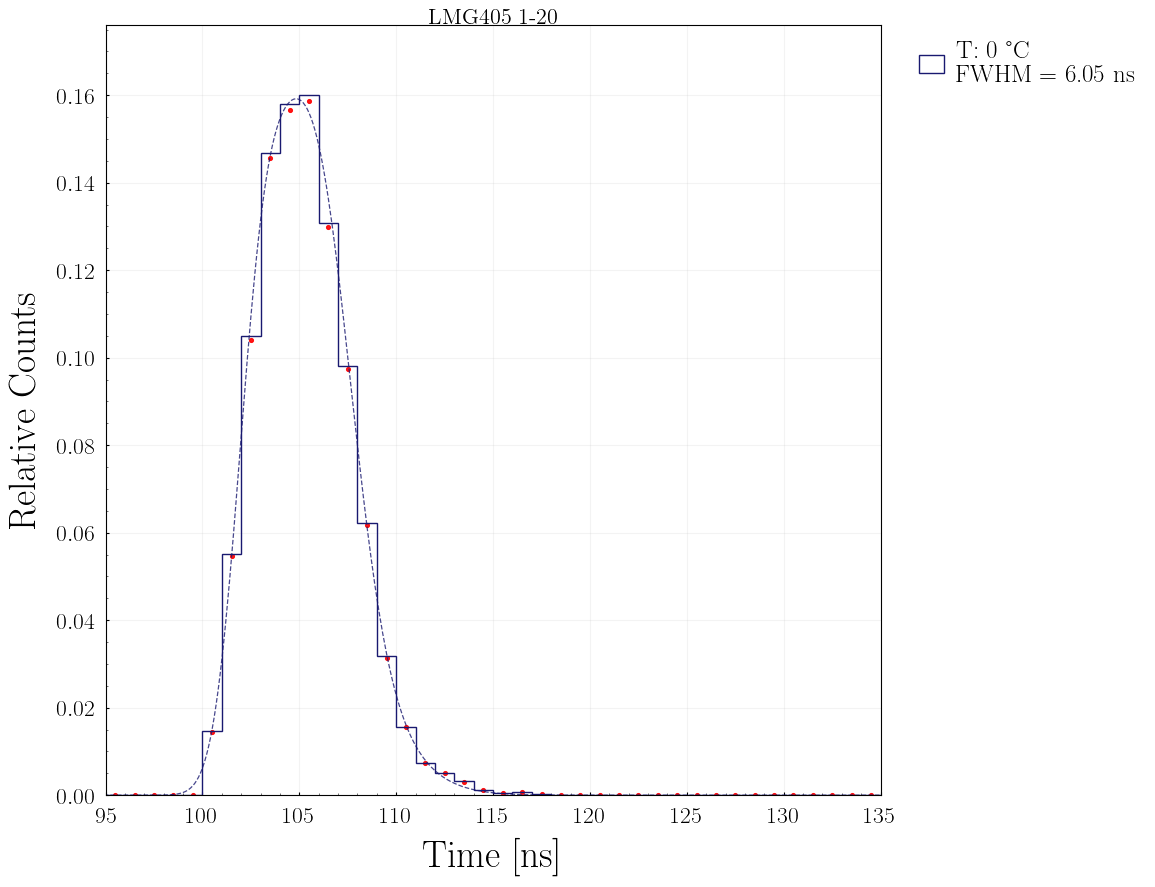

In [6]:
hem = '56'

pocam_device_number = '016'

emitter = 'LMG405'
double_peak = True

if 'LMG' in emitter:
    driver = 'l'               # 'l' for lmg
else:
    driver = 'k'

temp = 0

coarse = 1
fine = 20

mode = 'default'

power = 54000




    


# Setting up the dict to be stored as json file:
time_profile = {}     # this is the dict to be stored as the Database json file for the time profile data for one L(E)D


time_profile["device_uid"] = ''                   # "pocam-20240405_001"
time_profile["subdevice_uid"] = ''                # "pocam-led-{target}_{driver}-{emitter[-3:]}_{pocam_device_number}"
time_profile["meas_name"] = "pulse-time-profile"
time_profile["meas_class"] = "display"
time_profile["meas_stage"] = "calibration"
time_profile["meas_group"] = "timing"
time_profile["meas_site"] = "tum"
time_profile["meas_time"] = None                  # 1717684138.9665911 , in uinx time format
time_profile["meas_data"] = []






# Running the actual data inference (and plotting, etc.):
tdc = temp_dependent_tdc_data(hemisphere=hem,
                             temps = [temp],
                             # [25, 0, -10, -20, -30, -40]
                             diode = emitter,
                             power = power, 
                             coarse = coarse, fine = fine,
                             mode = mode,
                             double_peak=double_peak,
                             uncertainty=False,
                             plotting=True)




# specifying some more key-value pairs for identification etc.:
time_profile["device_uid"] = f"pocam-{tdc.date}_{pocam_device_number}"
if tdc.tdc.target == '1':
    target = 'master'
elif tdc.tdc.target == '2':
    target = 'slave'
time_profile["subdevice_uid"] = f"pocam-led-{target}_{driver}-{emitter[-3:]}_{pocam_device_number}"
time_profile["meas_time"] = tdc.tdc.meas_time




# sub-dictionaries to dump data in them:
# for each single spectral profile, specified by the used POCAM settings and the temp.,
# we have 3 sub-dict, one "graph-with-fit" for the spectral profile, one "value" for its CWL and one "value" for its FWHM


# "graph-with-fit":
hist_with_fit = {}
hist_with_fit["data_format"] = "hist-with-fit"
if 'LMG' in tdc.tdc.diode:
    hist_with_fit["coarse"] = tdc.coarse
    hist_with_fit["fine"] = tdc.fine
elif 'KAPU' in tdc.tdc.diode:
    hist_with_fit["mode"] = tdc.mode                                         # str: either 'default' or 'fast'
hist_with_fit["power"] = tdc.pwm                                             # integer
hist_with_fit["temperature"] = tdc.temp                                      # number (pos. or neg.), e.g. 25, 0, -20, etc.
hist_with_fit["x_label"] =  "Time [ns]"
hist_with_fit["y_label"] =  "Relative Counts"
hist_with_fit["y_values"] = (tdc.tdc.hist_counts_check/9000).tolist()        # array of normalized data
hist_with_fit["x_min"] = np.min(tdc.tdc.histogram_check_edges)
hist_with_fit["x_max"] = np.max(tdc.tdc.histogram_check_edges)
hist_with_fit["n_bins"] = len(tdc.tdc.histogram_check_edges) - 1
hist_with_fit["fit_x_min"] = np.min(tdc.x_fit_scan)
hist_with_fit["fit_x_max"] = np.max(tdc.x_fit_scan)
hist_with_fit["fit_n_bins"] = len(tdc.x_fit_scan)
hist_with_fit["fit_y_values"] = (tdc.fit_values).tolist()
hist_with_fit["title"] = "Time Profile of Single Emitted Pulses"
time_profile["meas_data"].append(hist_with_fit)



# "value" FWHM:
value_fwhm = {}
value_fwhm["data_format"] = "value"
value_fwhm["value"] = round( tdc.tdc.pocam_fwhm , 2 )
value_fwhm["error"] = round( tdc.tdc.pocam_fwhm_err , 2 )
if 'LMG' in tdc.diode:
    value_fwhm["coarse"] = tdc.coarse
    value_fwhm["fine"] = tdc.fine
elif 'KAPU' in tdc.diode:
    value_fwhm["mode"] = tdc.mode
value_fwhm["power"] = tdc.pwm
value_fwhm["temperature"] = tdc.temp
value_fwhm["label"] = "FWHM"
value_fwhm["title"] = "Full-Width-Half-Maximum [ns]"
time_profile["meas_data"].append(value_fwhm)









# We further add some comments and support files (links) to the json file:

# the comments are describing the data but can NOT be simply copy-pasted for all different L(E)Ds in general,
# as they are actually specifying on the exact data values,
# i.e. on giving information on the second peak for double peak scenarios.
# However the rest of the comments can be copy-pasted:
time_profile["comments"] =         [
                                    "The data shows the (statistically) reconstructed time profile of a single light pulse for the chosen L(E)D, operated at the specified parameters/conditions (temperature, applied voltage, pulse shape settings, etc.)",
                                    "The experimental data points represent a normalized (sum of all data points equals 1) histogram of the time profile for a single pulse.",
                                    "coarse and fine (for lmg-driven L(E)Ds), or mode (for kapu-driven L(E)Ds) are referring to the used pulse shape / time profile settings. ",
                                    "power is the numerical Pulse-Width-Modulation (PWM) value that is set to apply voltage, which handles emission intensities. (PWM is integer of 0 - 54000 corresponding to ~ 0 - 32 V)",
                                    "The experimental data shows true normalized counts of timestamps that tracked the arrival time of individual photons",
                                    "(If available) A fit function that can describe the time profile, based on the experimental data, is included in 'hist-with-fit'. The fit function is a Skew Gaussian distribution (mu, sigma, alpha) multiplied by some (unphysical) scaling factor.",
                                    "While the experimental data is structured in a way that 'x_min' is the most left edge and 'x_max' is the most right edge of a histogram and 'y_values' give the normalized counts for each of the bins, the fit_y_values are to be plotted as single points against an array of the same length specified by 'fit_x_min' and 'fit_x_max', including left and right end.",
                                    "Some L(E)Ds, especially the 520 nm emitters, show a second smaller peak in their time profile, which is modelled as an additional simple Gaussian distribution (mu_2, sigma_2) multiplied by its own (unphysical) scaling factor",
                                    "Mind that the fit-function is not yet to be used as true Probability-Density-Function (PDF), as its integral is not normalized to 1.",
                                    "(If available from fitting) The FWHM of the time profile at the given parameters and conditions is stored as a value, including its uncertainty. The value is the FWHM for the main peak. ",
                                    "The time profiles are shifted on the x-/time-axis in such a way that the pulses starts at ~ 100 ns. This offset with respect to 0 ns is unphysical. However it is a good approximation of internal POCAM delay between trigger and light emission.",
                                    "Some hemispheres are prone to clock jumps, which results in an instability of internal delays. Thus the time between sending a POCAM trigger signal and the actual light emission of single pulses may vary. Typically this is a jump of ~ 10 ns",
                                    "Structure of the device_uid: 'pocam-{date of measurement}_{pocam device number}",
                                    "Structure of the subdevice_uid: 'pocam-led_{target side}_{pulse driver}-{nominal emission wavelength}_{pocam device number} , where target side is either master (target 1) or slave (target 2) and pulse driver is either l (for lmg) or k (for kapu)"     
                                    ]
if double_peak == True:
    time_profile["comments"].append( f"The second, smaller peak is ~ {round(tdc.second_peak_delay,2)} ns delayed compared to the main peak, shows an approximate FWHM of ~ {round(tdc.second_peak_fwhm,2)} and an overall contribution of around ~ {100*round(tdc.second_peak_contr,4)} % to the total time profile." )
else:
    pass


# the support files contain one link where a POCAM_documentation file shall be uploaded,
# explaining data taking, processing and interpretation in a more detailed way
# but also contains the link to the specific raw data file(s) that is specified by the selected L(E)D
time_profile["support_files"] =    [
                                            {"filetype": "hdf5",
                                             "hostname": "data.icecube.wisc.edu",
                                             "pathname": f"/data/exp/IceCubeUpgrade/commissioning/pocam/pocam_{pocam_device_number}/{target}_hemisphere/{emitter}",
                                             "comment" : "Here you can find the raw data, stored as an hdf5 file. For more detailed info on the structure and interpretation of the data files please consult the POCAM documentation guide."
                                            },
                                            {"filetype": "pdf",
                                                 "hostname": "data.icecube.wisc.edu",
                                                 "pathname": "/data/exp/IceCubeUpgrade/commissioning/pocam/POCAM_documentation.pdf",
                                                 "comment" : "Here you can find the POCAM documentation guide, for more detailed info on the data taking, data processing, interpretation, etc.."
                                                }
                                    ]

In [5]:
time_profile

{'device_uid': 'pocam-20250413_016',
 'subdevice_uid': 'pocam-led-slave_k-405_016',
 'meas_name': 'pulse-time-profile',
 'meas_class': 'display',
 'meas_stage': 'calibration',
 'meas_group': 'timing',
 'meas_site': 'tum',
 'meas_time': 1744575423.117154,
 'meas_data': [{'data_format': 'hist-with-fit',
   'mode': 'default',
   'power': 54000,
   'temperature': -20,
   'x_label': 'Time [ns]',
   'y_label': 'Relative Counts',
   'y_values': [0.00011111111111111112,
    0.00011111111111111112,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.00011111111111111112,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.00022222222222222223,
    0.0,
    0.0,
    0.00133333333

In [ ]:
"""    
print()
hist_timestamps = tdc.tdc.hist_timestamps_check 
print("hist_timestamps (exp. x-data): ", len(tdc.tdc.hist_timestamps_check ))
print(hist_timestamps)

print()
hist_edges = tdc.tdc.histogram_check_edges
print("histogram_check_edges (exp. x-data): ", len(tdc.tdc.histogram_check_edges))
print(hist_edges)

print()
hist_counts = tdc.tdc.hist_counts_check/9000
print("hist_counts (exp. , normalized y-data): ", len(tdc.tdc.hist_counts_check))
print(hist_counts)
print(" -> max. (rel./norm.) hist count value: ", np.max(hist_counts))

print()
x_fit_scan = tdc.x_fit_scan
print("x_fit_scan (fit x-data): ", len(tdc.x_fit_scan))
print(x_fit_scan)

print()
fit_values = tdc.fit_values
print("fit_values (fit y-data): ", len(tdc.fit_values))
print(fit_values)
print(" -> max. fit value: ", np.max(fit_values))
"""
